# Phase 4 — Feature Engineering
Loads `data/cleaned.csv` (17,679 rows) and builds a model-ready feature matrix.

**Steps:**
1. Multi-hot encode tech columns (Language, Database, Webframe)
2. Ordinal encode education level
3. Extract primary role from DevType + one-hot encode
4. Map countries to 8 regions (reduce 177 → 8 categories)
5. Log-transform salary target
6. Drop collinear YearsCode (r=0.89 with WorkExp)
7. Train/test split 80/20, stratified by Region
8. Save `data/features.csv`, `data/X_train.csv`, `data/X_test.csv`, `data/y_train.csv`, `data/y_test.csv`

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

pd.set_option('display.max_columns', 60)
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

## Load Cleaned Data

In [2]:
df = pd.read_csv('../data/cleaned.csv', low_memory=False)
print(f'Loaded: {df.shape}')
print(f'Salary range: ${df["ConvertedCompYearly"].min():,.0f} – ${df["ConvertedCompYearly"].max():,.0f}')

Loaded: (17679, 172)
Salary range: $10,000 – $500,000


## Step 1 — Multi-hot Encode Tech Columns

In [3]:
def multihot(series, prefix, min_count=100):
    exploded = series.str.split(';').explode().str.strip()
    keep = exploded.value_counts()
    keep = keep[keep >= min_count].index.tolist()
    keep = [v for v in keep if v != 'Unknown']
    result = pd.DataFrame(index=series.index)
    for val in keep:
        col = prefix + val.replace(' ', '_').replace('/', '_').replace('-', '_').replace('.', '').replace('(', '').replace(')', '')
        result[col] = series.str.contains(val, regex=False, na=False).astype(int)
    return result

lang_df  = multihot(df['LanguageHaveWorkedWith'], prefix='lang_',  min_count=100)
db_df    = multihot(df['DatabaseHaveWorkedWith'],  prefix='db_',    min_count=100)
frame_df = multihot(df['WebframeHaveWorkedWith'],  prefix='frame_', min_count=100)

print(f'Language features : {lang_df.shape[1]}  — {list(lang_df.columns)}')
print(f'Database features : {db_df.shape[1]}  — {list(db_df.columns)}')
print(f'Framework features: {frame_df.shape[1]}  — {list(frame_df.columns)}')

Language features : 40  — ['lang_JavaScript', 'lang_HTML_CSS', 'lang_SQL', 'lang_Python', 'lang_Bash_Shell_all_shells', 'lang_TypeScript', 'lang_C#', 'lang_Java', 'lang_PowerShell', 'lang_C++', 'lang_Go', 'lang_C', 'lang_PHP', 'lang_Rust', 'lang_Kotlin', 'lang_Lua', 'lang_Ruby', 'lang_Groovy', 'lang_Swift', 'lang_Assembly', 'lang_Dart', 'lang_R', 'lang_Visual_Basic_Net', 'lang_VBA', 'lang_Perl', 'lang_GDScript', 'lang_MATLAB', 'lang_Scala', 'lang_Elixir', 'lang_Lisp', 'lang_Delphi', 'lang_Zig', 'lang_MicroPython', 'lang_Erlang', 'lang_F#', 'lang_Fortran', 'lang_Gleam', 'lang_OCaml', 'lang_COBOL', 'lang_Ada']
Database features : 28  — ['db_PostgreSQL', 'db_MySQL', 'db_SQLite', 'db_Microsoft_SQL_Server', 'db_Redis', 'db_MongoDB', 'db_MariaDB', 'db_Elasticsearch', 'db_Dynamodb', 'db_Oracle', 'db_BigQuery', 'db_Cosmos_DB', 'db_H2', 'db_Snowflake', 'db_Supabase', 'db_InfluxDB', 'db_Cloud_Firestore', 'db_Databricks_SQL', 'db_DuckDB', 'db_Microsoft_Access', 'db_Firebase_Realtime_Database', 'd

## Step 2 — Ordinal Encode Education Level

In [4]:
ed_order = {
    'Primary/elementary school': 0,
    'Secondary school (e.g. American high school, German Realschule or Gymnasium, etc.)': 1,
    'Some college/university study without earning a degree': 2,
    'Associate degree (A.A., A.S., etc.)': 3,
    "Bachelor's degree (B.A., B.S., B.Eng., etc.)": 4,
    "Master's degree (M.A., M.S., M.Eng., MBA, etc.)": 5,
    'Professional degree (JD, MD, Ph.D, Ed.D, etc.)': 6,
    'Other (please specify):': 2,
    'Unknown': 2,
}

df['EdLevel_ord'] = df['EdLevel'].map(ed_order)
print(df['EdLevel_ord'].value_counts().sort_index().to_string())

EdLevel_ord
0.0      53
1.0     724
2.0    2060
3.0     611
6.0    1080


## Step 3 — Primary Role + One-hot Encode DevType

In [5]:
df['PrimaryRole'] = df['DevType'].str.split(';').str[0].str.strip()

role_counts = df['PrimaryRole'].value_counts()
keep_roles  = role_counts[role_counts >= 50].index
df['PrimaryRole'] = df['PrimaryRole'].where(df['PrimaryRole'].isin(keep_roles), other='Other')

role_dummies = pd.get_dummies(df['PrimaryRole'], prefix='role', drop_first=False)
print(f'Role dummy columns: {role_dummies.shape[1]}')
print(df['PrimaryRole'].value_counts().to_string())

Role dummy columns: 29
PrimaryRole
Developer, full-stack                            5551
Developer, back-end                              3028
Architect, software or solutions                 1264
Developer, desktop or enterprise applications     896
Developer, front-end                              797
Developer, embedded applications or devices       639
Engineering manager                               624
Other (please specify):                           579
DevOps engineer or professional                   577
Developer, mobile                                 519
Data engineer                                     393
Academic researcher                               368
Data scientist                                    273
AI/ML engineer                                    270
Senior executive (C-suite, VP, etc.)              232
Cloud infrastructure engineer                     213
System administrator                              183
Developer, QA or test                          

## Step 4 — Country → Region Mapping

In [6]:
region_map = {
    # North America
    'United States of America': 'North_America',
    'Canada': 'North_America',
    'Mexico': 'North_America',
    # Western Europe
    'Germany': 'Western_Europe',
    'France': 'Western_Europe',
    'United Kingdom of Great Britain and Northern Ireland': 'Western_Europe',
    'Netherlands': 'Western_Europe',
    'Switzerland': 'Western_Europe',
    'Austria': 'Western_Europe',
    'Belgium': 'Western_Europe',
    'Sweden': 'Western_Europe',
    'Denmark': 'Western_Europe',
    'Norway': 'Western_Europe',
    'Finland': 'Western_Europe',
    'Ireland': 'Western_Europe',
    'Italy': 'Western_Europe',
    'Spain': 'Western_Europe',
    'Portugal': 'Western_Europe',
    'Greece': 'Western_Europe',
    # Eastern Europe
    'Ukraine': 'Eastern_Europe',
    'Poland': 'Eastern_Europe',
    'Romania': 'Eastern_Europe',
    'Czech Republic': 'Eastern_Europe',
    'Hungary': 'Eastern_Europe',
    'Slovakia': 'Eastern_Europe',
    'Bulgaria': 'Eastern_Europe',
    'Serbia': 'Eastern_Europe',
    'Croatia': 'Eastern_Europe',
    'Russia': 'Eastern_Europe',
    'Belarus': 'Eastern_Europe',
    'Lithuania': 'Eastern_Europe',
    'Latvia': 'Eastern_Europe',
    'Estonia': 'Eastern_Europe',
    'Slovenia': 'Eastern_Europe',
    # South Asia
    'India': 'South_Asia',
    'Pakistan': 'South_Asia',
    'Bangladesh': 'South_Asia',
    'Sri Lanka': 'South_Asia',
    'Nepal': 'South_Asia',
    # East / SE Asia
    'China': 'East_SE_Asia',
    'Japan': 'East_SE_Asia',
    'South Korea': 'East_SE_Asia',
    'Singapore': 'East_SE_Asia',
    'Taiwan': 'East_SE_Asia',
    'Vietnam': 'East_SE_Asia',
    'Indonesia': 'East_SE_Asia',
    'Philippines': 'East_SE_Asia',
    'Malaysia': 'East_SE_Asia',
    'Thailand': 'East_SE_Asia',
    # Latin America
    'Brazil': 'Latin_America',
    'Argentina': 'Latin_America',
    'Colombia': 'Latin_America',
    'Chile': 'Latin_America',
    'Peru': 'Latin_America',
    'Venezuela, Bolivarian Republic of...': 'Latin_America',
    'Ecuador': 'Latin_America',
    'Uruguay': 'Latin_America',
    # Middle East & Africa
    'Israel': 'Middle_East_Africa',
    'United Arab Emirates': 'Middle_East_Africa',
    'Turkey': 'Middle_East_Africa',
    'Egypt': 'Middle_East_Africa',
    'Nigeria': 'Middle_East_Africa',
    'South Africa': 'Middle_East_Africa',
    'Saudi Arabia': 'Middle_East_Africa',
    'Iran, Islamic Republic of...': 'Middle_East_Africa',
    # Oceania
    'Australia': 'Oceania',
    'New Zealand': 'Oceania',
}

df['Region'] = df['Country'].map(region_map).fillna('Other')
print(df['Region'].value_counts().to_string())

Region
Western_Europe        7345
North_America         5262
Eastern_Europe        1630
South_Asia             718
Latin_America          706
Oceania                593
Other                  514
Middle_East_Africa     497
East_SE_Asia           414


In [7]:
region_dummies = pd.get_dummies(df['Region'], prefix='region', drop_first=False)
print(f'Region dummy columns: {region_dummies.shape[1]} — {list(region_dummies.columns)}')

Region dummy columns: 9 — ['region_East_SE_Asia', 'region_Eastern_Europe', 'region_Latin_America', 'region_Middle_East_Africa', 'region_North_America', 'region_Oceania', 'region_Other', 'region_South_Asia', 'region_Western_Europe']


## Step 5 — Log-transform Salary Target

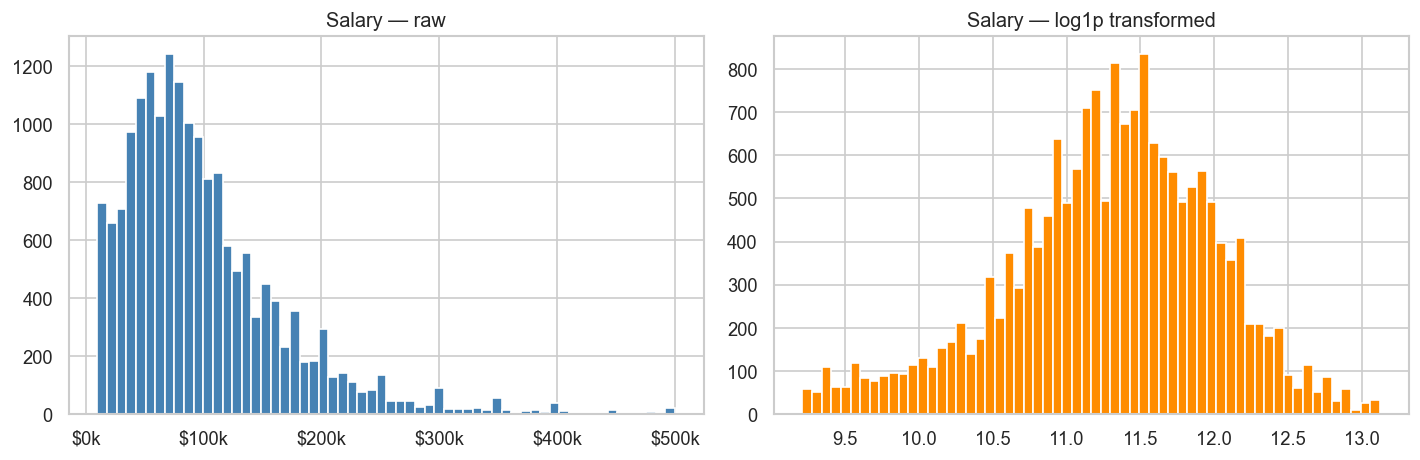

log_salary: mean=11.284  std=0.715


In [8]:
df['log_salary'] = np.log1p(df['ConvertedCompYearly'])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(df['ConvertedCompYearly'], bins=60, color='steelblue', edgecolor='white')
axes[0].set_title('Salary — raw')
axes[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x/1e3:.0f}k'))
axes[1].hist(df['log_salary'], bins=60, color='darkorange', edgecolor='white')
axes[1].set_title('Salary — log1p transformed')
plt.tight_layout()
plt.savefig('../reports/log_salary_transform.png', bbox_inches='tight')
plt.show()
print(f"log_salary: mean={df['log_salary'].mean():.3f}  std={df['log_salary'].std():.3f}")

## Step 6 — Assemble Feature Matrix

In [9]:
# Drop YearsCode — collinear with WorkExp (r=0.89, identified in EDA Phase 2)
feature_df = pd.concat([
    df[['WorkExp', 'EdLevel_ord']],
    lang_df,
    db_df,
    frame_df,
    role_dummies,
    region_dummies,
], axis=1)

print(f'Feature matrix shape: {feature_df.shape}')
print(f'Total features     : {feature_df.shape[1]}')
print(feature_df.dtypes.value_counts())

Feature matrix shape: (17679, 136)
Total features     : 136
int64      96
bool       38
float64     2
Name: count, dtype: int64


## Step 7 — Train / Test Split (80/20, stratified by Region)

In [10]:
X = feature_df.copy()
y = df['log_salary'].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=df['Region']
)

print(f'X_train: {X_train.shape}  |  X_test: {X_test.shape}')
print(f'y_train: {y_train.shape}  |  y_test: {y_test.shape}')
print()
print('Region distribution in train set:')
print(df.loc[X_train.index, 'Region'].value_counts().to_string())

X_train: (14143, 136)  |  X_test: (3536, 136)
y_train: (14143,)  |  y_test: (3536,)

Region distribution in train set:
Region
Western_Europe        5876
North_America         4210
Eastern_Europe        1304
South_Asia             574
Latin_America          565
Oceania                474
Other                  411
Middle_East_Africa     398
East_SE_Asia           331


## Step 8 — Save Outputs

In [11]:
feature_df['log_salary'] = df['log_salary']
feature_df.to_csv('../data/features.csv', index=False)

X_train.to_csv('../data/X_train.csv', index=False)
X_test.to_csv('../data/X_test.csv',   index=False)
y_train.to_csv('../data/y_train.csv', index=False)
y_test.to_csv('../data/y_test.csv',   index=False)

print('Saved:')
print(f'  data/features.csv — {feature_df.shape}')
print(f'  data/X_train.csv  — {X_train.shape}')
print(f'  data/X_test.csv   — {X_test.shape}')
print(f'  data/y_train.csv  — {y_train.shape}')
print(f'  data/y_test.csv   — {y_test.shape}')

C:\Users\SAMBIT\AppData\Local\Temp\ipykernel_49824\3407208838.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  feature_df['log_salary'] = df['log_salary']


Saved:
  data/features.csv — (17679, 137)
  data/X_train.csv  — (14143, 136)
  data/X_test.csv   — (3536, 136)
  data/y_train.csv  — (14143,)
  data/y_test.csv   — (3536,)


## Phase 4 Summary

| Step | Action | Result |
|------|--------|--------|
| 1 | Multi-hot encode Language / Database / Webframe | 40 lang + 28 db + 28 frame = **96 binary tech features** |
| 2 | Ordinal encode EdLevel | 7-level scale (0=Primary → 6=PhD) |
| 3 | Primary role + one-hot encode DevType | **29 role dummy columns** (full-stack 5,551 · back-end 3,028 · architect 1,264) |
| 4 | Country → 8 Regions | Western Europe 7,345 · North America 5,262 · Eastern Europe 1,630 · South Asia 718 · Latin America 706 · Oceania 593 · Other 514 · Middle East/Africa 497 · East/SE Asia 414 |
| 5 | Log1p salary target | mean=11.284 · std=0.715 |
| 6 | Drop YearsCode, assemble feature matrix | **136 total features** (2 numeric + 96 tech + 29 role + 9 region) |
| 7 | Train/test split 80/20 stratified by Region | X_train: (14,143 × 136) · X_test: (3,536 × 136) |
| 8 | Save all outputs |  (17,679 × 137) · , , ,  saved |